 DESCRIPTIVE STATISTICS: 
  Margarine         Time     mean       std  count
0         A  After4weeks  5.46875  1.387603      8
1         A  After8weeks  5.40875  1.373707      8
2         A       Before  5.94500  1.428126      8
3         B  After4weeks  6.14000  0.814589     10
4         B  After8weeks  6.07500  0.778835     10
5         B       Before  6.77800  0.866472     10

 Mixed Model ANOVA 
                       Mixed Linear Model Regression Results
Model:                      MixedLM         Dependent Variable:         Cholesterol
No. Observations:           54              Method:                     REML       
No. Groups:                 18              Scale:                      0.0083     
Min. group size:            3               Log-Likelihood:             -8.4583    
Max. group size:            3               Converged:                  Yes        
Mean group size:            3.0                                                    
-------------------------------

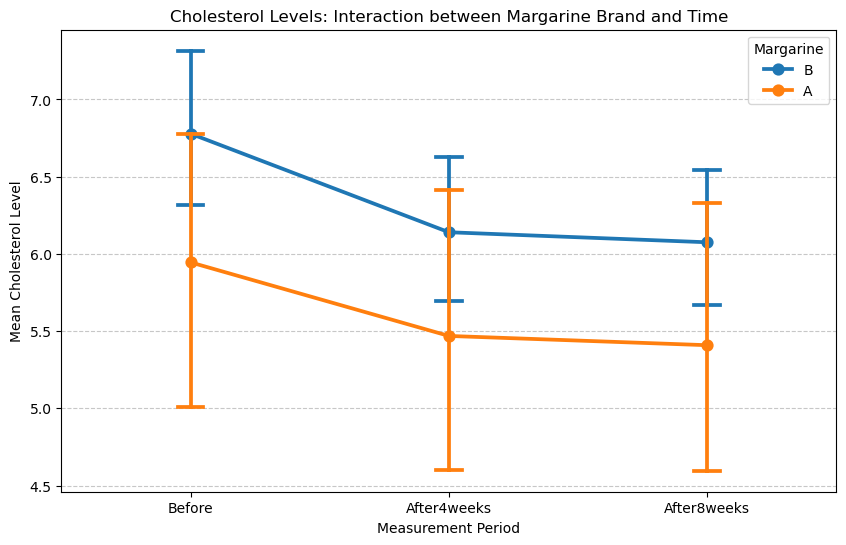

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import scipy.stats as st

#dataset
df = pd.read_csv('Cholesterol_Dataset.csv')
df_long = pd.melt(df, id_vars=['ID', 'Margarine'],
                  value_vars=['Before', 'After4weeks', 'After8weeks'],
                  var_name='Time', value_name='Cholesterol')

#calculates descriptive statistics
desc_stats = df_long.groupby(['Margarine', 'Time'])['Cholesterol'].agg(['mean', 'std', 'count']).reset_index()
print(" DESCRIPTIVE STATISTICS: ")
print(desc_stats)

#anova results
model = smf.mixedlm("Cholesterol ~ C(Margarine) * C(Time)", df_long, groups=df_long["ID"])
result = model.fit()

print("\n Mixed Model ANOVA ")
print(result.summary())

model_no_interaction = smf.mixedlm("Cholesterol ~ C(Margarine) + C(Time)", df_long, groups=df_long["ID"])
result_no_interaction = model_no_interaction.fit()

print(result_no_interaction.summary())
llf_full = result.llf
llf_restricted = result_no_interaction.llf
lrt_stat = 2 * (llf_full - llf_restricted)
df_lrt = len(result.params) - len(result_no_interaction.params)

p_value = st.chi2.sf(lrt_stat, df_lrt)

print(f"P-value: {p_value:.4f}")

#graph
plt.figure(figsize=(10, 6))
sns.pointplot(data=df_long, x='Time', y='Cholesterol', hue='Margarine', 
              order=['Before', 'After4weeks', 'After8weeks'], capsize=.1)
plt.title('Cholesterol Levels: Interaction between Margarine Brand and Time')
plt.ylabel('Mean Cholesterol Level')
plt.xlabel('Measurement Period')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('cholesterol_interaction_plot.png')

### ***APA Report***

This study was conducted using a two-way mixed model ANOVA to assess the two different margarine brands' effect (which are Brand A and Brand B) to the participants in terms of cholesterol levels over three time points (Before, 4 weeks, and 8 weeks). The significant main effect of the margarine brands are F(1, 48) = 5.66, p = 0.021. On average, the participants those using the Brand B possible had higher cholesterol levels (M = 6.33), compered to those using Brand A (M = 5.61). In this case, the main effect of time was not statistically significant F(2, 48) = 1.75, p = 0.184. While a general decrease that observed on this case, from the baseline (M = 6.41) to 8 weeks (M = 5.78) this trend did not reach the limit for significance in this model. For interaction effect, there was no significant between the what type of margarine and time, F(2, 48) = 0.03, p = 0.968. Which indicates that the reduction in cholesterol levels over time followed a similar pattern for both margarine brands. In conclusion, fail to reject the null hypothesis regarding the interaction effect there is no significant difference in how the two brands affected cholesterol levels over the three time points. However, it show the significant difference in the baseline/overall levels between the two groups assigned to the brands.